# Gráficas de litio desde datos Fortran

Este notebook **solo grafica** a partir de archivos Fortran guardados en `finite-diferences/`:

- `potential_litio_fortran.dat`
- `funciones_radiales_litio_fortran.dat`
- `energias_litio_fortran.dat`

No recalcula espectro ni potencial en Python.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

hartree_to_ev = 27.211386245988
base = Path('.')
df_dir = base / 'finite-diferences'

pot_file = df_dir / 'potential_litio_fortran.dat'
wf_file = df_dir / 'funciones_radiales_litio_fortran.dat'
ene_file = df_dir / 'energias_litio_fortran.dat'

assert pot_file.exists(), f'No existe {pot_file}'
assert wf_file.exists(), f'No existe {wf_file}'
assert ene_file.exists(), f'No existe {ene_file}'

pot = np.loadtxt(pot_file, comments='#')
wf = np.loadtxt(wf_file, comments='#')

# Si energias_litio_fortran.dat tiene estado,l,E(Ha),E(eV), usamos la ultima columna.
energies = {}
with open(ene_file, 'r', encoding='utf-8') as f:
    for line in f:
        if line.strip().startswith('#') or not line.strip():
            continue
        parts = line.split()
        state = parts[0]
        e_ev = float(parts[-1])
        energies[state] = e_ev

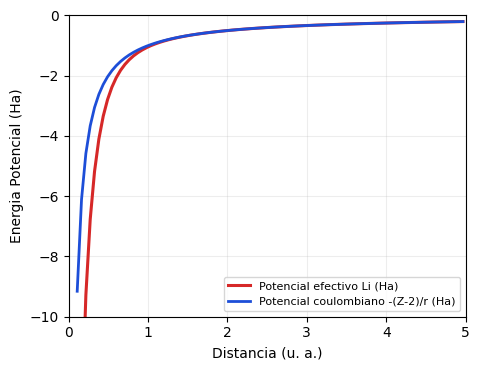

In [6]:
# Columnas: r, Vc(Ha), Veff(Ha)
r = pot[:, 0]
vc_ha = pot[:, 1]
veff_ha = pot[:, 2]

# Escala en Hartree y aspecto similar al documento
mask = (r >= 0.10) & (r <= 5.0)

fig, ax = plt.subplots(figsize=(4.9, 3.8))
ax.plot(
    r[mask], veff_ha[mask],
    lw=2.2, color='#d62828', label='Potencial efectivo Li (Ha)'
)
ax.plot(
    r[mask], vc_ha[mask],
    lw=2.0, color='#1d4ed8', label='Potencial coulombiano -(Z-2)/r (Ha)'
)
ax.set_xlim(0.0, 5.0)
ax.set_ylim(-10.0, 0.0)
ax.set_xlabel('Distancia (u. a.)')
ax.set_ylabel('Energia Potencial (Ha)')
ax.grid(alpha=0.22)
ax.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()

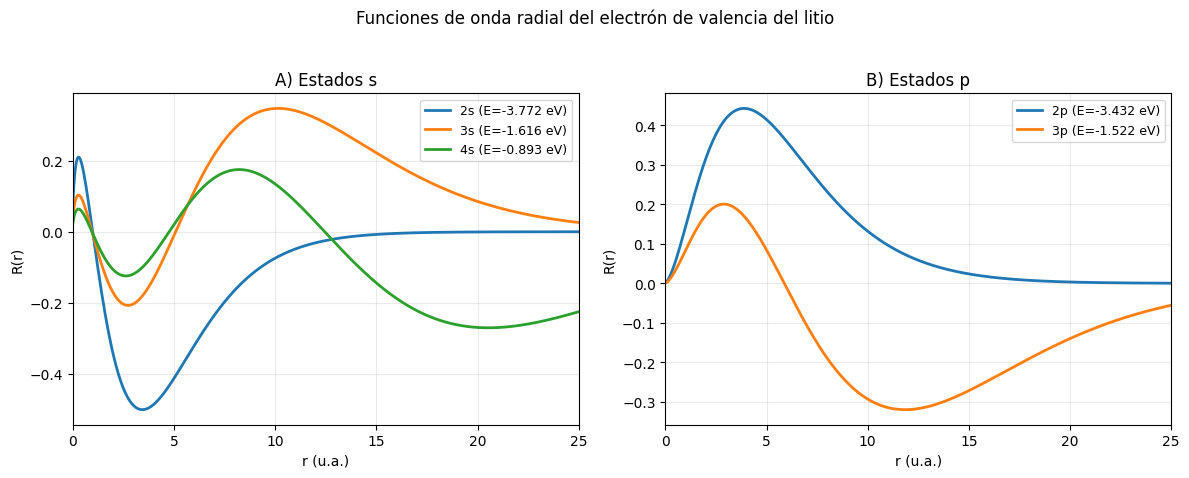

In [7]:
# Columnas: r, R_2s, R_3s, R_4s, R_2p, R_3p
rw = wf[:, 0]
r2s, r3s, r4s, r2p, r3p = wf[:, 1], wf[:, 2], wf[:, 3], wf[:, 4], wf[:, 5]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharex=True)

axes[0].plot(rw, r2s, lw=2.0, label=f"2s (E={energies.get('2s', np.nan):.3f} eV)")
axes[0].plot(rw, r3s, lw=2.0, label=f"3s (E={energies.get('3s', np.nan):.3f} eV)")
axes[0].plot(rw, r4s, lw=2.0, label=f"4s (E={energies.get('4s', np.nan):.3f} eV)")
axes[0].set_xlim(0.0, 25.0)
axes[0].set_xlabel('r (u.a.)')
axes[0].set_ylabel('R(r)')
axes[0].set_title('A) Estados s')
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=9)

axes[1].plot(rw, r2p, lw=2.0, label=f"2p (E={energies.get('2p', np.nan):.3f} eV)")
axes[1].plot(rw, r3p, lw=2.0, label=f"3p (E={energies.get('3p', np.nan):.3f} eV)")
axes[1].set_xlim(0.0, 25.0)
axes[1].set_xlabel('r (u.a.)')
axes[1].set_ylabel('R(r)')
axes[1].set_title('B) Estados p')
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=9)

plt.suptitle('Funciones de onda radial del electrón de valencia del litio', y=1.03)
plt.tight_layout()
plt.show()

## Comparacion Fortran vs C++ vs Python desde DAT

Esta seccion usa exclusivamente `comparacion_lenguajes.dat` para mostrar:

- tiempo de ejecucion
- energia 2s
- error relativo
- iteraciones variacionales
- numero de estados extraidos (s y p)

Tabla comparativa (desde comparacion_lenguajes.dat)
language | time_s | var_iter | e2s_ev | err_rel_ion | err_rel_2s | n_s | n_p
fortran |  0.30142 |        3 |  -3.7715 | 4.715498e-04 | 3.002701e-01 |   3 |   2
    cpp |  0.24127 |        3 |  -3.7715 | 4.716259e-04 | 3.002701e-01 |   3 |   2
     py |  8.12867 |        3 |  -3.7715 | 4.716259e-04 | 3.002701e-01 |   3 |   2


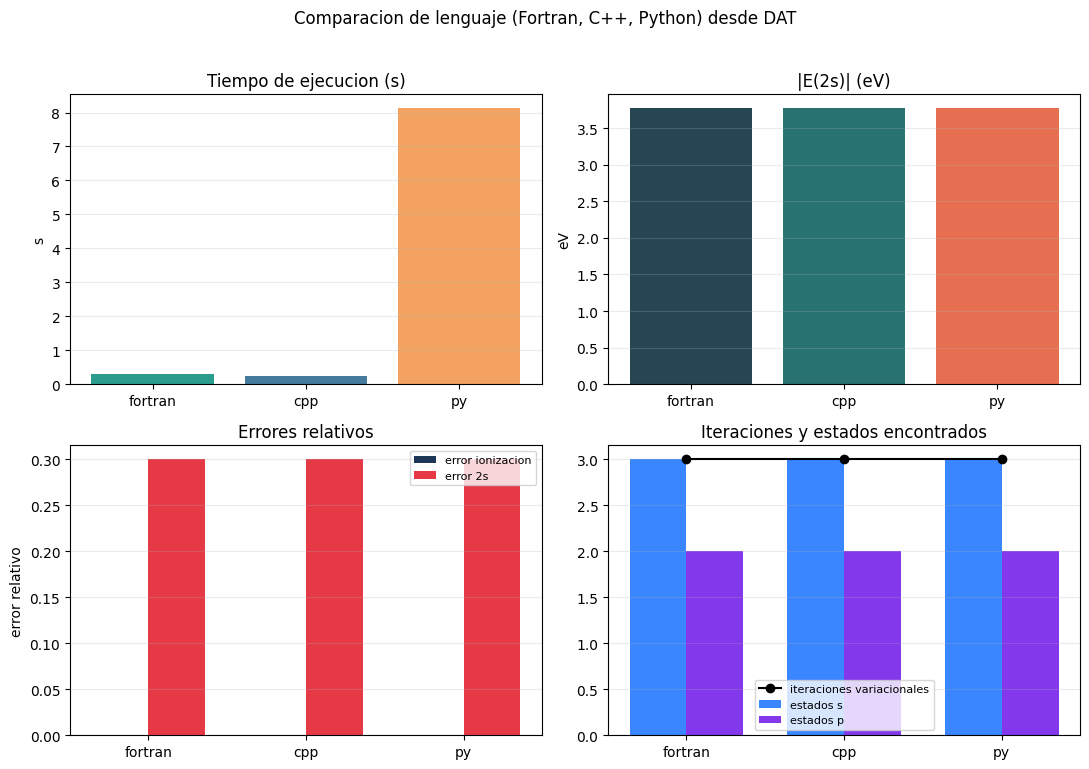

In [8]:
cmp_file = base / 'comparacion_lenguajes.dat'
assert cmp_file.exists(), f'No existe {cmp_file}'

cmp = np.genfromtxt(cmp_file, comments='#', dtype=None, encoding='utf-8')
if cmp.ndim == 0:
    cmp = np.array([cmp], dtype=cmp.dtype)

langs = cmp['f0']
time_s = cmp['f1'].astype(float)
var_iter = cmp['f2'].astype(int)
e2s_ev = cmp['f5'].astype(float)
err_ion = cmp['f6'].astype(float)
err_2s = cmp['f7'].astype(float)
n_s = cmp['f8'].astype(int)
n_p = cmp['f9'].astype(int)

print('Tabla comparativa (desde comparacion_lenguajes.dat)')
print('language | time_s | var_iter | e2s_ev | err_rel_ion | err_rel_2s | n_s | n_p')
for i in range(len(langs)):
    print(f"{langs[i]:>7} | {time_s[i]:8.5f} | {var_iter[i]:8d} | {e2s_ev[i]:8.4f} | {err_ion[i]:11.6e} | {err_2s[i]:11.6e} | {n_s[i]:3d} | {n_p[i]:3d}")

x = np.arange(len(langs))
fig, axes = plt.subplots(2, 2, figsize=(11, 7.5))

axes[0, 0].bar(x, time_s, color=['#2a9d8f', '#457b9d', '#f4a261'])
axes[0, 0].set_xticks(x, langs)
axes[0, 0].set_title('Tiempo de ejecucion (s)')
axes[0, 0].set_ylabel('s')
axes[0, 0].grid(axis='y', alpha=0.25)

axes[0, 1].bar(x, np.abs(e2s_ev), color=['#264653', '#287271', '#e76f51'])
axes[0, 1].set_xticks(x, langs)
axes[0, 1].set_title('|E(2s)| (eV)')
axes[0, 1].set_ylabel('eV')
axes[0, 1].grid(axis='y', alpha=0.25)

width = 0.36
axes[1, 0].bar(x - width / 2, err_ion, width=width, label='error ionizacion', color='#1d3557')
axes[1, 0].bar(x + width / 2, err_2s, width=width, label='error 2s', color='#e63946')
axes[1, 0].set_xticks(x, langs)
axes[1, 0].set_title('Errores relativos')
axes[1, 0].set_ylabel('error relativo')
axes[1, 0].grid(axis='y', alpha=0.25)
axes[1, 0].legend(fontsize=8)

axes[1, 1].bar(x - width / 2, n_s, width=width, label='estados s', color='#3a86ff')
axes[1, 1].bar(x + width / 2, n_p, width=width, label='estados p', color='#8338ec')
axes[1, 1].plot(x, var_iter, marker='o', color='black', label='iteraciones variacionales')
axes[1, 1].set_xticks(x, langs)
axes[1, 1].set_title('Iteraciones y estados encontrados')
axes[1, 1].grid(axis='y', alpha=0.25)
axes[1, 1].legend(fontsize=8)

plt.suptitle('Comparacion de lenguaje (Fortran, C++, Python) desde DAT', y=1.02)
plt.tight_layout()
plt.show()